# scGPT Embeddings → Cell-Type Classification (PDAC)

**Dataset**: `PDAC_ADJ_Final_Annotated.h5ad` — 71,074 cells × 36,601 genes  
**Labels**: `scGPT_target_label` — 14 cell types  
**Strategy**: Zero-shot scGPT_human embeddings → Logistic Regression + MLP  

> Set runtime to **T4 GPU**: Runtime → Change runtime type → T4 GPU

---
## 0. Install dependencies

In [1]:
!pip install scgpt scanpy anndata scikit-learn umap-learn matplotlib seaborn --quiet

try:
    import faiss
    print('faiss already available')
except ImportError:
    !pip install faiss-cpu --quiet
    print('faiss-cpu installed')

import torch
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

faiss already available
PyTorch 2.11.0+cu130 | CUDA: True


---
## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 2. Configuration

In [3]:
from pathlib import Path

DATA_DIR       = Path("/content/drive/MyDrive/CompGenProject/data")
ANNOTATED_FILE = DATA_DIR / "PDAC_ADJ_Final_Annotated.h5ad"
MODEL_DIR      = Path("/content/drive/MyDrive/scGPT_human")  # pretrained scGPT_human weights

CELL_TYPE_KEY  = "scGPT_target_label"   # 14 cell-type classes
GENE_COL       = "index"                # gene names stored in adata.var_names
BATCH_SIZE     = 64

print(f'Annotated file : {ANNOTATED_FILE}')
print(f'Model dir      : {MODEL_DIR}')
print(f'Model dir exists: {MODEL_DIR.exists()}')

Annotated file : /content/drive/MyDrive/CompGenProject/data/PDAC_ADJ_Final_Annotated.h5ad
Model dir      : /content/drive/MyDrive/scGPT_human
Model dir exists: True


---
## 3. Load data

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np

adata = sc.read_h5ad(ANNOTATED_FILE)
print(f'Shape: {adata.shape}  (cells x genes)')
print(f'X range: [{adata.X.min():.3f}, {adata.X.max():.3f}]  (log-normalised counts)')
print()
print('Cell-type distribution:')
print(adata.obs[CELL_TYPE_KEY].value_counts().to_string())

Shape: (71074, 36601)  (cells x genes)
X range: [0.000, 9.043]  (log-normalised counts)

Cell-type distribution:
scGPT_target_label
T-Cells        21108
Ductal         11118
Fibroblasts    10050
Acinar          8315
Macrophages     6194
B-Cells         4411
Endothelial     3247
Neutrophils     2368
Stellate        1567
Mast             989
Plasma           708
Endocrine        407
NK               405
Schwann          187
Unknown            0


---
## 4. Generate scGPT embeddings (zero-shot)

Maps each cell to a **512-dimensional embedding** using `scGPT_human`. No fine-tuning needed.

> Expected time: ~5-10 min on T4 GPU for 71k cells.

In [ ]:
!pip install huggingface_hub --quiet

from huggingface_hub import snapshot_download
import os

model_save_dir = "/content/drive/MyDrive/scGPT_human"
os.makedirs(model_save_dir, exist_ok=True)

snapshot_download(
    repo_id="wanglab/scGPT-human",
    local_dir=model_save_dir,
    repo_type="model",
    token=""
)

print("Downloaded files:")
for f in os.listdir(model_save_dir):
    print(f"  {f}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Downloaded files:
  .cache
  best_model.pt
  .gitattributes
  args.json
  vocab.json


In [6]:
import sys
from unittest.mock import MagicMock

# Build a minimal real Vocab-like class that satisfies GeneVocab's __init__
class FakeVocab:
    def __init__(self, tokens):
        self._tokens = tokens
        self._stoi = {t: i for i, t in enumerate(tokens)}
        self._itos = tokens

    @property
    def vocab(self):
        return self  # GeneVocab calls _vocab.vocab, so return self

    def __len__(self):
        return len(self._tokens)

    def __contains__(self, token):
        return token in self._stoi

    def __getitem__(self, token):
        return self._stoi.get(token, 0)

    def get_itos(self):
        return self._itos

    def get_stoi(self):
        return self._stoi

# Patch torchtext
torchtext_mock = MagicMock()
torchtext_mock.vocab.Vocab = FakeVocab
torchtext_mock.vocab.build_vocab_from_iterator = MagicMock()
sys.modules['torchtext'] = torchtext_mock
sys.modules['torchtext.vocab'] = torchtext_mock.vocab

import scgpt as scg
print("scgpt imported successfully")

/usr/local/lib/python3.12/dist-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/usr/local/lib/python3.12/dist-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


scgpt imported successfully


In [7]:
# Directly patch the installed scGPT file to remove torchtext dependency
patch_code = '''import json
import pickle
from pathlib import Path
from collections import Counter, OrderedDict
from typing import Dict, Iterable, List, Optional, Tuple, Union
from typing_extensions import Self

import numpy as np
import pandas as pd
import torch

from .. import logger


class GeneVocab:
    """Vocabulary for genes. Patched to remove torchtext dependency."""

    def __init__(self, gene_list_or_vocab, specials=None, special_first=True, default_token="<pad>"):
        if isinstance(gene_list_or_vocab, GeneVocab):
            self._stoi = dict(gene_list_or_vocab._stoi)
            self._itos = list(gene_list_or_vocab._itos)
        elif isinstance(gene_list_or_vocab, list):
            built = self._build_vocab_from_iterator(gene_list_or_vocab, specials=specials, special_first=special_first)
            self._stoi = built._stoi
            self._itos = built._itos
        else:
            raise ValueError("gene_list_or_vocab must be a list or GeneVocab object.")
        self._default_index = None
        if default_token is not None and default_token in self:
            self.set_default_token(default_token)

    def _build_vocab_from_iterator(self, iterator, min_freq=1, specials=None, special_first=True):
        counter = Counter()
        counter.update(iterator)
        if specials is not None:
            for tok in specials:
                del counter[tok]
        sorted_tuples = sorted(counter.items(), key=lambda x: x[0])
        sorted_tuples.sort(key=lambda x: x[1], reverse=True)
        tokens = [t for t, _ in sorted_tuples]
        if specials is not None:
            if special_first:
                tokens = specials + tokens
            else:
                tokens = tokens + specials
        v = GeneVocab.__new__(GeneVocab)
        v._itos = tokens
        v._stoi = {t: i for i, t in enumerate(tokens)}
        v._default_index = None
        return v

    @classmethod
    def from_file(cls, file_path):
        file_path = Path(file_path)
        if file_path.suffix == ".pkl":
            with file_path.open("rb") as f:
                vocab = pickle.load(f)
                return cls(vocab)
        elif file_path.suffix == ".json":
            with file_path.open("r") as f:
                token2idx = json.load(f)
                return cls.from_dict(token2idx)
        else:
            raise ValueError(f"{file_path} is not a valid file type.")

    @classmethod
    def from_dict(cls, token2idx, default_token="<pad>"):
        v = cls.__new__(cls)
        v._default_index = None
        sorted_tokens = sorted(token2idx.items(), key=lambda x: x[1])
        v._itos = [t for t, _ in sorted_tokens]
        v._stoi = {t: i for i, t in enumerate(v._itos)}
        if default_token is not None and default_token in v:
            v.set_default_token(default_token)
        return v

    def __len__(self):
        return len(self._itos)

    def __contains__(self, token):
        return token in self._stoi

    def __getitem__(self, token):
        if token in self._stoi:
            return self._stoi[token]
        if self._default_index is not None:
            return self._default_index
        raise KeyError(f"{token} not in vocabulary")

    def get_stoi(self):
        return self._stoi

    def get_itos(self):
        return self._itos

    def insert_token(self, token, index):
        if token not in self._stoi:
            self._itos.insert(index, token)
            self._stoi = {t: i for i, t in enumerate(self._itos)}

    def append_token(self, token):
        if token not in self._stoi:
            self._stoi[token] = len(self._itos)
            self._itos.append(token)

    def set_default_index(self, index):
        self._default_index = index

    def set_default_token(self, token):
        if token not in self:
            raise ValueError(f"{token} is not in the vocabulary.")
        self.set_default_index(self[token])

    @property
    def pad_token(self):
        if getattr(self, "_pad_token", None) is None:
            self._pad_token = None
        return self._pad_token

    @pad_token.setter
    def pad_token(self, pad_token):
        if pad_token not in self:
            raise ValueError(f"{pad_token} is not in the vocabulary.")
        self._pad_token = pad_token

    def save_json(self, file_path):
        file_path = Path(file_path)
        with file_path.open("w") as f:
            json.dump(self.get_stoi(), f, indent=2)


# Keep remaining functions identical but use GeneVocab instead of Vocab type hints
def get_default_gene_vocab():
    vocab_file = Path(__file__).parent / "default_gene_vocab.json"
    if not vocab_file.exists():
        return _build_default_gene_vocab(save_vocab_to=vocab_file)
    return GeneVocab.from_file(vocab_file)


def _build_default_gene_vocab(download_source_to="/tmp", save_vocab_to=None):
    gene_collection_file = Path(download_source_to) / "human.gene_name_symbol.from_genenames.org.tsv"
    if not gene_collection_file.exists():
        url = ("https://www.genenames.org/cgi-bin/download/custom?col=gd_app_sym&"
               "col=md_ensembl_id&status=Approved&status=Entry%20Withdrawn&hgnc_dbtag"
               "=on&order_by=gd_app_sym_sort&format=text&submit=submit")
        import requests
        r = requests.get(url)
        gene_collection_file.write_text(r.text)
    df = pd.read_csv(gene_collection_file, sep="\\t")
    gene_list = df["Approved symbol"].dropna().unique().tolist()
    gene_vocab = GeneVocab(gene_list)
    if save_vocab_to is not None:
        gene_vocab.save_json(Path(save_vocab_to))
    return gene_vocab


def tokenize_batch(data, gene_ids, return_pt=True, append_cls=True, include_zero_gene=False,
                   cls_id=0, mod_type=None, cls_id_mod_type=None):
    if data.shape[1] != len(gene_ids):
        raise ValueError(f"Number of features in data ({data.shape[1]}) does not match number of gene_ids ({len(gene_ids)}).")
    tokenized_data = []
    for i in range(len(data)):
        row = data[i]
        mod_types = None
        if include_zero_gene:
            values = row
            genes = gene_ids
            if mod_type is not None:
                mod_types = mod_type
        else:
            idx = np.nonzero(row)[0]
            values = row[idx]
            genes = gene_ids[idx]
            if mod_type is not None:
                mod_types = mod_type[idx]
        if append_cls:
            genes = np.insert(genes, 0, cls_id)
            values = np.insert(values, 0, 0)
            if mod_type is not None:
                mod_types = np.insert(mod_types, 0, cls_id_mod_type)
        if return_pt:
            genes = torch.from_numpy(genes).long()
            values = torch.from_numpy(values).float()
            if mod_type is not None:
                mod_types = torch.from_numpy(mod_types).long()
        tokenized_data.append((genes, values, mod_types))
    return tokenized_data


def pad_batch(batch, max_len, vocab, pad_token="<pad>", pad_value=0, cls_appended=True, vocab_mod=None):
    max_ori_len = max(len(batch[i][0]) for i in range(len(batch)))
    max_len = min(max_ori_len, max_len)
    pad_id = vocab[pad_token]
    gene_ids_list, values_list, mod_types_list = [], [], []
    for i in range(len(batch)):
        gene_ids, values, mod_types = batch[i]
        if len(gene_ids) > max_len:
            if not cls_appended:
                idx = np.random.choice(len(gene_ids), max_len, replace=False)
            else:
                idx = np.random.choice(len(gene_ids) - 1, max_len - 1, replace=False)
                idx = idx + 1
                idx = np.insert(idx, 0, 0)
            gene_ids = gene_ids[idx]
            values = values[idx]
            if mod_types is not None:
                mod_types = mod_types[idx]
        if len(gene_ids) < max_len:
            gene_ids = torch.cat([gene_ids, torch.full((max_len - len(gene_ids),), pad_id, dtype=gene_ids.dtype)])
            values = torch.cat([values, torch.full((max_len - len(values),), pad_value, dtype=values.dtype)])
        gene_ids_list.append(gene_ids)
        values_list.append(values)
    batch_padded = {"genes": torch.stack(gene_ids_list, dim=0), "values": torch.stack(values_list, dim=0)}
    return batch_padded


def tokenize_and_pad_batch(data, gene_ids, max_len, vocab, pad_token, pad_value,
                            append_cls=True, include_zero_gene=False, cls_token="<cls>",
                            return_pt=True, mod_type=None, vocab_mod=None):
    cls_id = vocab[cls_token]
    tokenized_data = tokenize_batch(data, gene_ids, return_pt=return_pt, append_cls=append_cls,
                                     include_zero_gene=include_zero_gene, cls_id=cls_id,
                                     mod_type=mod_type, cls_id_mod_type=None)
    return pad_batch(tokenized_data, max_len, vocab, pad_token, pad_value, cls_appended=append_cls)


def random_mask_value(values, mask_ratio=0.15, mask_value=-1, pad_value=0):
    if isinstance(values, torch.Tensor):
        values = values.clone().detach().numpy()
    else:
        values = values.copy()
    for i in range(len(values)):
        row = values[i]
        non_padding_idx = np.nonzero(row - pad_value)[0]
        n_mask = int(len(non_padding_idx) * mask_ratio)
        mask_idx = np.random.choice(non_padding_idx, n_mask, replace=False)
        row[mask_idx] = mask_value
    return torch.from_numpy(values).float()
'''

# Write the patched file
with open("/usr/local/lib/python3.12/dist-packages/scgpt/tokenizer/gene_tokenizer.py", "w") as f:
    f.write(patch_code)

print("Patched successfully. Now importing scgpt...")

import importlib
import scgpt
import scgpt.tokenizer
import scgpt.tokenizer.gene_tokenizer
importlib.reload(scgpt.tokenizer.gene_tokenizer)
importlib.reload(scgpt.tokenizer)
importlib.reload(scgpt)
import scgpt as scg
print("Done!")

Patched successfully. Now importing scgpt...
Done!


In [8]:
with open("/usr/local/lib/python3.12/dist-packages/scgpt/tokenizer/gene_tokenizer.py", "r") as f:
    content = f.read()

# Insert __call__ right after __getitem__
old = "    def get_stoi(self):"
new = """    def __call__(self, tokens):
        if isinstance(tokens, list):
            return [self[t] for t in tokens]
        return self[tokens]

    def get_stoi(self):"""

content = content.replace(old, new)

with open("/usr/local/lib/python3.12/dist-packages/scgpt/tokenizer/gene_tokenizer.py", "w") as f:
    f.write(content)

print("Done. Now go to Runtime → Restart session, then re-run all cells.")

Done. Now go to Runtime → Restart session, then re-run all cells.


In [9]:
import scgpt as scg

embed_adata = scg.tasks.embed_data(
    adata,
    MODEL_DIR,
    gene_col=GENE_COL,
    obs_to_save=CELL_TYPE_KEY,
    batch_size=BATCH_SIZE,
    return_new_adata=True,
)

print(f'Embedding shape: {embed_adata.X.shape}')  # (71074, 512)

scGPT - INFO - match 24285/36601 genes in vocabulary of size 60697.


/usr/local/lib/python3.12/dist-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scgpt/tasks/cell_emb.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=True):
Embedding cells: 100%|██████████| 1111/1111 [12:27<00:00,  1.49it/s]


Embedding shape: (71074, 512)


/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


In [10]:
# Save embeddings — skip scGPT on future runs by loading this file directly
EMBED_PATH = DATA_DIR / "PDAC_ADJ_scgpt_embeddings.h5ad"
embed_adata.write_h5ad(EMBED_PATH)
print(f'Saved to {EMBED_PATH}')

# To reload later:
# embed_adata = sc.read_h5ad(EMBED_PATH)

Saved to /content/drive/MyDrive/CompGenProject/data/PDAC_ADJ_scgpt_embeddings.h5ad


---
## 5. Visualise embeddings with UMAP

In [11]:
# Disable the CUDA version check in torchvision
with open("/usr/local/lib/python3.12/dist-packages/torchvision/extension.py", "r") as f:
    content = f.read()

content = content.replace(
    "raise RuntimeError(",
    "pass  # raise RuntimeError("
)

with open("/usr/local/lib/python3.12/dist-packages/torchvision/extension.py", "w") as f:
    f.write(content)

print("Patched. Now do Runtime → Restart session and re-run all cells.")

Patched. Now do Runtime → Restart session and re-run all cells.


In [12]:
import sys
from unittest.mock import MagicMock

# Prevent torchvision from crashing UMAP/scanpy
sys.modules['torchvision'] = MagicMock()
sys.modules['torchvision.extension'] = MagicMock()

sc.pp.neighbors(embed_adata, use_rep="X", n_neighbors=15)
sc.tl.umap(embed_adata)

In [13]:
# In the embedding cell, use this instead of embed_data:
embed_adata = sc.read_h5ad(DATA_DIR / "PDAC_ADJ_scgpt_embeddings.h5ad")
print(f'Loaded: {embed_adata.X.shape}')

Loaded: (71074, 512)


In [15]:
# Merge original obs columns back into embed_adata
embed_adata.obs = adata.obs.loc[embed_adata.obs_names].copy()
print(embed_adata.obs.columns.tolist())

['gsm', 'sample_id', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_0.8', 'leiden_0.1', 'leiden_0.2', 'leiden_0.5', 'leiden_0.4', 'global_cell_type', 'leiden_0.9', 'broad_cell_types', 'pdac_cell_types', 'adj_cell_types', 'pdac_annotation', 'adj_annotation', 'scGPT_target_label']


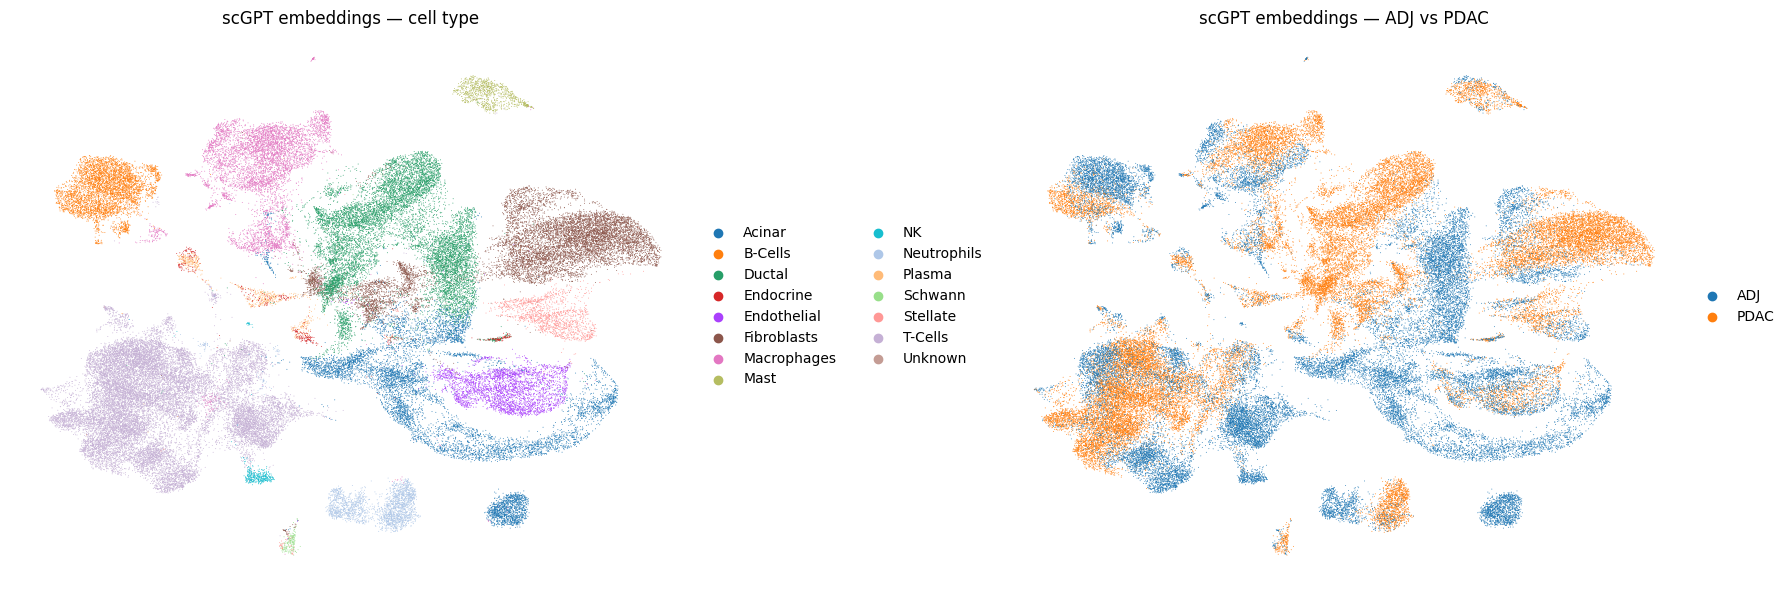

In [16]:
import matplotlib.pyplot as plt

sc.pp.neighbors(embed_adata, use_rep="X", n_neighbors=15)
sc.tl.umap(embed_adata)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sc.pl.umap(embed_adata, color=CELL_TYPE_KEY, frameon=False,
           title="scGPT embeddings — cell type", ax=axes[0], show=False)
sc.pl.umap(embed_adata, color="condition", frameon=False,
           title="scGPT embeddings — ADJ vs PDAC", ax=axes[1], show=False)
plt.tight_layout()
plt.savefig("umap_scgpt_zeroshot.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Prepare features and labels

Patient Stratification

In [37]:
from sklearn.model_selection import train_test_split

# Patient-level split — no patient appears in both train and test
all_samples = adata.obs['sample_id'].unique()
train_samples, test_samples = train_test_split(
    all_samples, test_size=0.2, random_state=42
)

print(f'Train samples: {sorted(train_samples)}')
print(f'Test samples:  {sorted(test_samples)}')

train_mask = adata.obs['sample_id'].isin(train_samples).values
test_mask  = adata.obs['sample_id'].isin(test_samples).values

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

Train samples: ['ADJ1', 'ADJ2', 'ADJ3', 'ADJ6', 'PDAC2', 'PDAC3', 'PDAC4', 'PDAC5', 'PDAC6']
Test samples:  ['ADJ4', 'ADJ5', 'PDAC1']

Train: (52481, 512)  |  Test: (18593, 512)


---
## 7. Logistic Regression (linear baseline)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

print('Training Logistic Regression...')
lr = LogisticRegression(
    max_iter=1000, C=1.0, solver="lbfgs",
    multi_class="multinomial", random_state=42, n_jobs=-1
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {acc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9598

              precision    recall  f1-score   support

      Acinar       0.97      0.91      0.94      3877
     B-Cells       0.99      0.99      0.99       239
      Ductal       0.95      0.96      0.95      3742
   Endocrine       0.67      0.79      0.73       156
 Endothelial       0.98      0.98      0.98      1454
 Fibroblasts       0.94      0.97      0.96      2361
 Macrophages       0.93      0.98      0.96      1514
        Mast       0.99      0.98      0.99       510
          NK       0.85      0.61      0.71        28
 Neutrophils       0.99      0.99      0.99       181
      Plasma       0.88      0.81      0.84       151
     Schwann       0.86      0.79      0.83        63
    Stellate       0.94      0.96      0.95       462
     T-Cells       0.99      0.99      0.99      3855

    accuracy                           0.96     18593
   macro avg       0.92      0.91      0.91     18593
weighted avg       0.96      0.96      0.96     18593



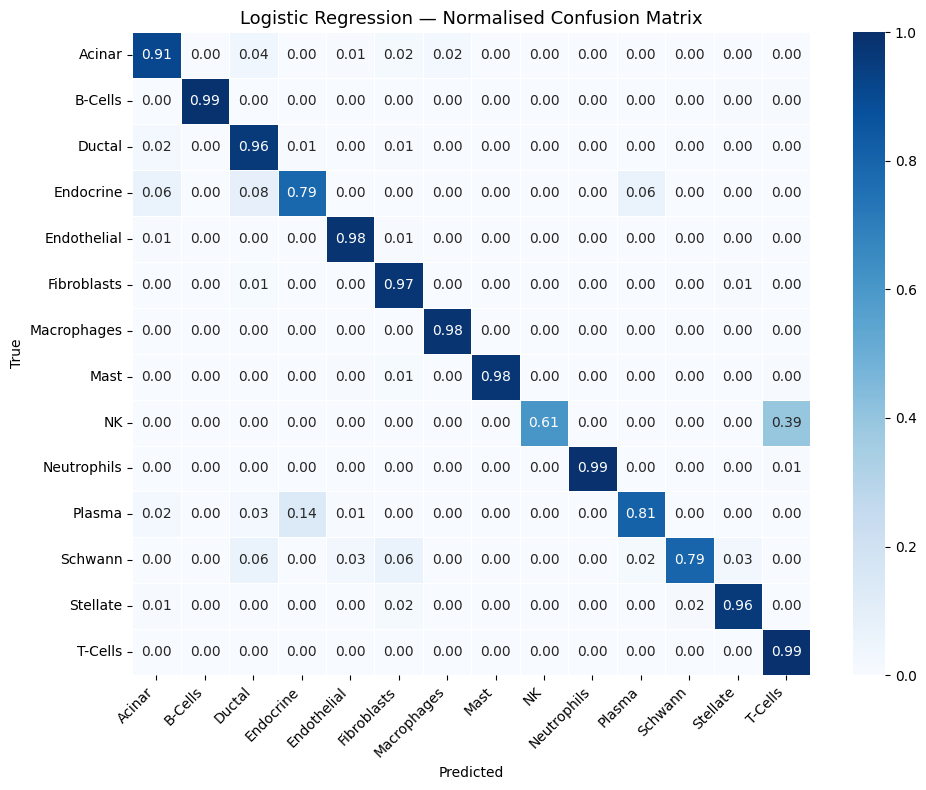

In [28]:
def plot_cm(y_true, y_pred, class_names, title, cmap, save_path):
    cm = confusion_matrix(y_true, y_pred).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)   # row-normalise
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=class_names,
                yticklabels=class_names, cmap=cmap, vmin=0, vmax=1,
                linewidths=0.4, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_cm(y_test, y_pred_lr, le.classes_,
        "Logistic Regression — Normalised Confusion Matrix",
        "Blues", "cm_logistic_regression.png")

---
## 8. MLP Classifier (PyTorch)

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')

X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.long)

train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=512, shuffle=True, pin_memory=True)


class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, n_classes, dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP(512, [256, 128], n_classes, dropout=0.3).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Device: cuda
MLP(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=14, bias=True)
  )
)
Parameters: 166,798


In [30]:
EPOCHS   = 60
LR       = 1e-3
PATIENCE = 10

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

train_losses, val_accs = [], []
best_val_acc, patience_counter = 0.0, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)

    model.eval()
    with torch.no_grad():
        val_acc = (model(X_te.to(device)).argmax(1).cpu() == y_te).float().mean().item()

    avg_loss = epoch_loss / len(X_tr)
    train_losses.append(avg_loss)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={avg_loss:.4f}  val_acc={val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_mlp.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}  (best={best_val_acc:.4f})')
            break

print(f'Best MLP val accuracy: {best_val_acc:.4f}')

Epoch   1/60  loss=0.3541  val_acc=0.9456
Epoch   5/60  loss=0.0549  val_acc=0.9582
Epoch  10/60  loss=0.0405  val_acc=0.9643
Epoch  15/60  loss=0.0333  val_acc=0.9598
Epoch  20/60  loss=0.0301  val_acc=0.9623
Epoch  25/60  loss=0.0227  val_acc=0.9670
Epoch  30/60  loss=0.0187  val_acc=0.9663
Epoch  35/60  loss=0.0180  val_acc=0.9645
Epoch  40/60  loss=0.0149  val_acc=0.9671
Early stopping at epoch 43  (best=0.9696)
Best MLP val accuracy: 0.9696


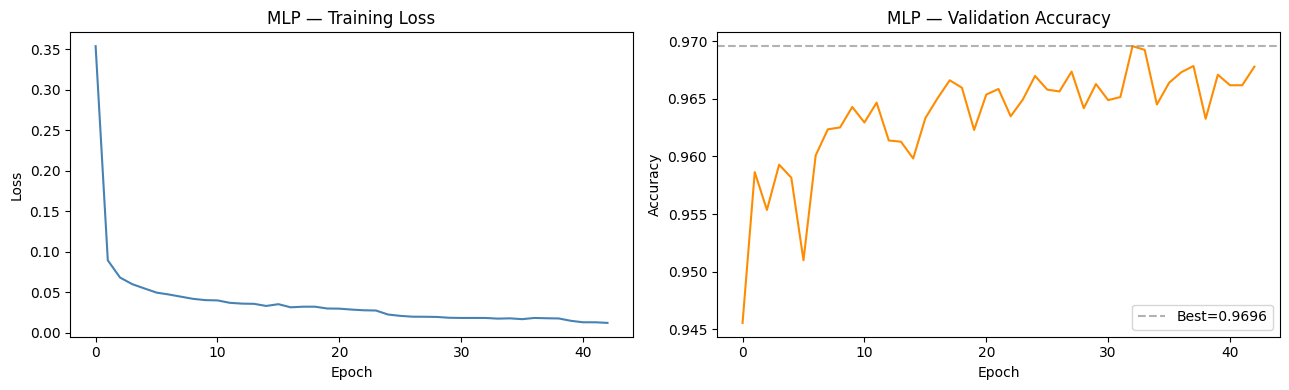

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, color="steelblue")
axes[0].set(xlabel="Epoch", ylabel="Loss", title="MLP — Training Loss")
axes[1].plot(val_accs, color="darkorange")
axes[1].axhline(best_val_acc, linestyle="--", color="gray", alpha=0.6, label=f"Best={best_val_acc:.4f}")
axes[1].legend()
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="MLP — Validation Accuracy")
plt.tight_layout()
plt.savefig("mlp_training_curves.png", dpi=150)
plt.show()

In [32]:
model.load_state_dict(torch.load("best_mlp.pt"))
model.eval()
with torch.no_grad():
    y_pred_mlp = model(X_te.to(device)).argmax(1).cpu().numpy()

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f'MLP accuracy (best checkpoint): {acc_mlp:.4f}')
print()
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

MLP accuracy (best checkpoint): 0.9696

              precision    recall  f1-score   support

      Acinar       0.97      0.94      0.96      3877
     B-Cells       0.98      0.99      0.99       239
      Ductal       0.96      0.96      0.96      3742
   Endocrine       0.72      0.79      0.76       156
 Endothelial       0.98      0.98      0.98      1454
 Fibroblasts       0.96      0.98      0.97      2361
 Macrophages       0.97      0.98      0.98      1514
        Mast       0.99      0.99      0.99       510
          NK       0.91      0.75      0.82        28
 Neutrophils       0.99      0.99      0.99       181
      Plasma       0.92      0.86      0.89       151
     Schwann       0.83      0.83      0.83        63
    Stellate       0.96      0.96      0.96       462
     T-Cells       0.99      0.99      0.99      3855

    accuracy                           0.97     18593
   macro avg       0.94      0.93      0.93     18593
weighted avg       0.97      0.97      0

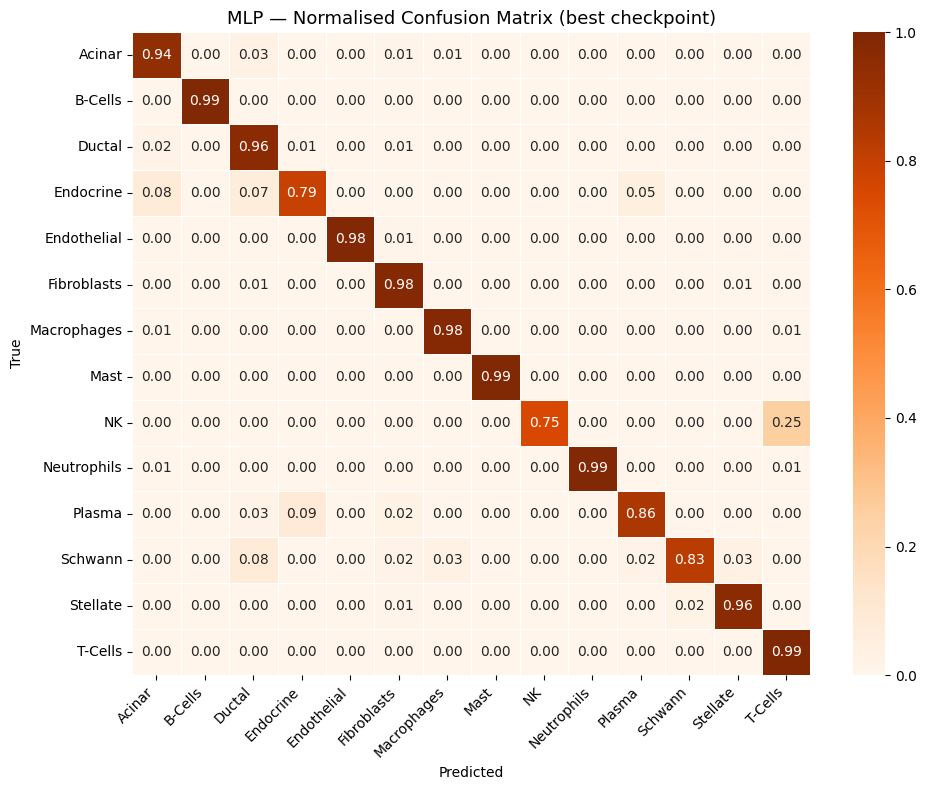

In [33]:
plot_cm(y_test, y_pred_mlp, le.classes_,
        "MLP — Normalised Confusion Matrix (best checkpoint)",
        "Oranges", "cm_mlp.png")

---
## 9. Summary comparison

                  Model  Test Accuracy
    Logistic Regression       0.959770
MLP (512->256->128->14)       0.969558


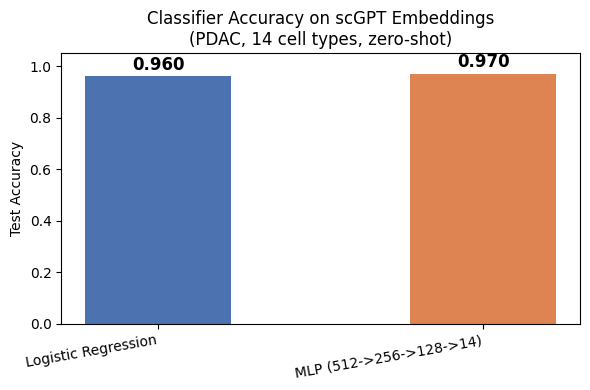

In [34]:
results = pd.DataFrame({
    "Model":         ["Logistic Regression", "MLP (512->256->128->14)"],
    "Test Accuracy": [acc_lr, acc_mlp],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(results["Model"], results["Test Accuracy"],
              color=["#4C72B0", "#DD8452"], width=0.45)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("Classifier Accuracy on scGPT Embeddings\n(PDAC, 14 cell types, zero-shot)")
for bar, acc in zip(bars, results["Test Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

---
## 10. UMAP: ground truth vs MLP predictions

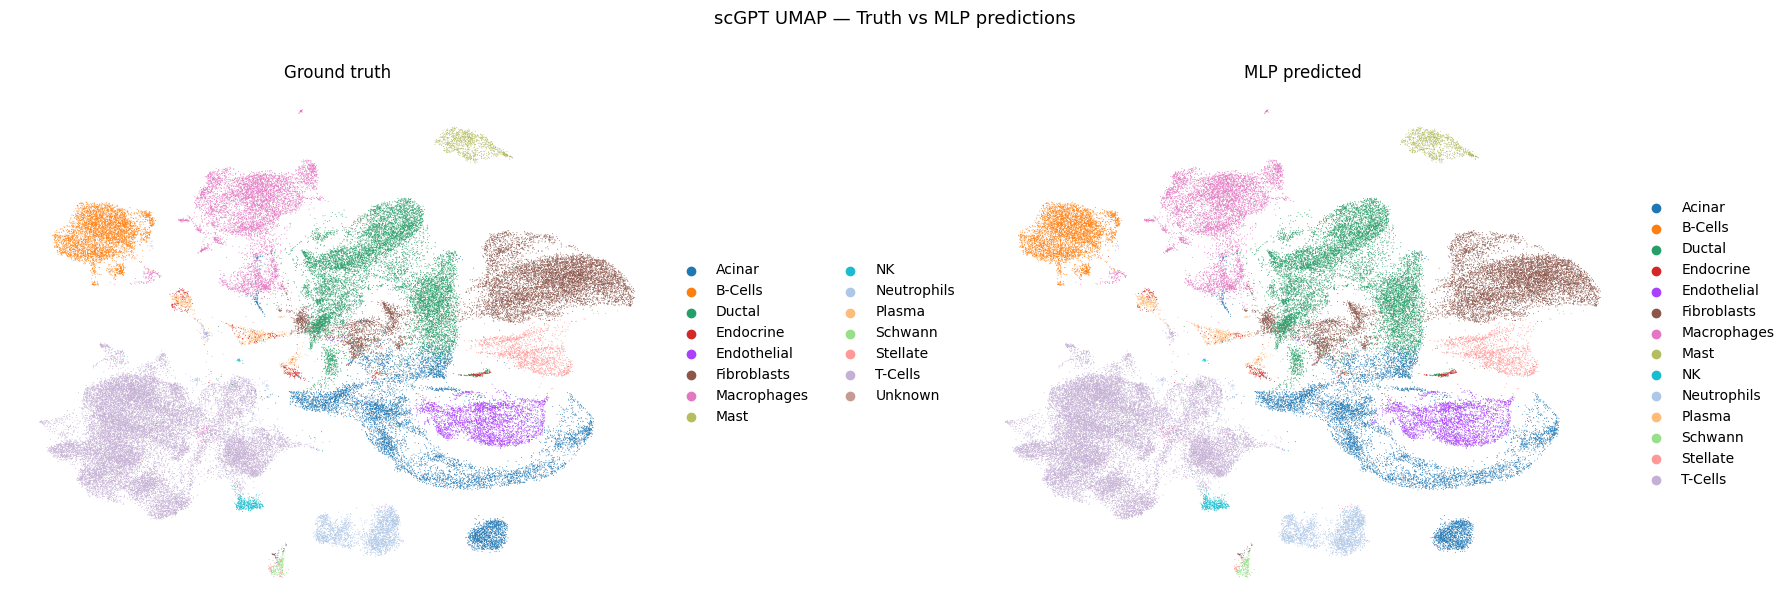

In [35]:
# Predict on ALL cells for visualisation
model.eval()
X_all_scaled = torch.tensor(scaler.transform(embed_adata.X.copy()), dtype=torch.float32)
all_dl = DataLoader(TensorDataset(X_all_scaled), batch_size=1024, shuffle=False)

all_preds = []
with torch.no_grad():
    for (xb,) in all_dl:
        all_preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
all_preds = np.concatenate(all_preds)
embed_adata.obs["mlp_pred"] = le.inverse_transform(all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sc.pl.umap(embed_adata, color=CELL_TYPE_KEY, frameon=False,
           title="Ground truth", ax=axes[0], show=False)
sc.pl.umap(embed_adata, color="mlp_pred", frameon=False,
           title="MLP predicted", ax=axes[1], show=False)
plt.suptitle("scGPT UMAP — Truth vs MLP predictions", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("umap_truth_vs_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 11. Save outputs

In [36]:
pred_df = pd.DataFrame({
    "cell_barcode": embed_adata.obs_names,
    "condition":    embed_adata.obs["condition"].values,
    "sample_id":    embed_adata.obs["sample_id"].values,
    "true_label":   embed_adata.obs[CELL_TYPE_KEY].values,
    "mlp_pred":     embed_adata.obs["mlp_pred"].values,
})
pred_df.to_csv("PDAC_predictions.csv", index=False)

embed_adata.write_h5ad(DATA_DIR / "PDAC_ADJ_scgpt_embeddings_with_preds.h5ad")

print('Saved: PDAC_predictions.csv')
print('Saved: PDAC_ADJ_scgpt_embeddings_with_preds.h5ad')
print('Saved: best_mlp.pt')

Saved: PDAC_predictions.csv
Saved: PDAC_ADJ_scgpt_embeddings_with_preds.h5ad
Saved: best_mlp.pt


In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# scGPT's native approach: KNN majority vote on embeddings (no training)
knn = KNeighborsClassifier(n_neighbors=10, metric='euclidean', n_jobs=-1)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f'KNN (scGPT-style, k=10) accuracy: {acc_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

KNN (scGPT-style, k=10) accuracy: 0.9599

              precision    recall  f1-score   support

      Acinar       0.96      0.92      0.94      3877
     B-Cells       0.99      1.00      0.99       239
      Ductal       0.94      0.96      0.95      3742
   Endocrine       0.77      0.55      0.64       156
 Endothelial       0.98      0.99      0.99      1454
 Fibroblasts       0.94      0.97      0.96      2361
 Macrophages       0.96      0.97      0.96      1514
        Mast       0.99      0.98      0.99       510
          NK       0.84      0.93      0.88        28
 Neutrophils       0.96      0.99      0.98       181
      Plasma       0.79      0.85      0.82       151
     Schwann       0.79      0.83      0.81        63
    Stellate       0.98      0.94      0.96       462
     T-Cells       0.99      0.99      0.99      3855

    accuracy                           0.96     18593
   macro avg       0.92      0.92      0.92     18593
weighted avg       0.96      0.96     

In [39]:
results = pd.DataFrame({
    "Model": [
        "KNN k=10 (scGPT native)",
        "Logistic Regression",
        "MLP (512→256→128→14)"
    ],
    "Test Accuracy": [acc_knn, acc_lr, acc_mlp],
})
print(results.to_string(index=False))

                  Model  Test Accuracy
KNN k=10 (scGPT native)       0.959877
    Logistic Regression       0.959770
   MLP (512→256→128→14)       0.969558
